# Mini-Project — Data Analysis for Marketing Strategy
## Week 2 — Day 5

**Dataset:** US Superstore Dataset.

**Questions answered**
1. Which states have the most sales?
2. New York vs California — sales and profit comparison.
3. Who is an outstanding customer in New York?
4. Profitability differences across states.
5. Pareto Principle on customers and profit.
6. Top 20 cities by sales / profit + profitability differences.
7. Top 20 customers by sales.
8. Cumulative Sales curve + Pareto check on customers and sales.
9. Marketing strategy recommendations.

All comments are in English.

## 1. Loading and Preprocessing

In [1]:
# ==================== IMPORTS ====================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
BASE_DIR = os.getcwd()

In [2]:
# ==================== LOAD DATASET ====================
# The Superstore CSV uses ISO-8859-1 (latin-1) encoding because of accented product names.
df = pd.read_csv(os.path.join(BASE_DIR, 'superstore_dataset.csv'), encoding='latin-1')

print('Shape:', df.shape)
print('\nColumns:', list(df.columns))
df.head()

Shape: (51290, 24)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,42433,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,TB-11280,Toby Braunhardt,Consumer,Constantine,Constantine,...,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408.300,2,0.0,106.140,35.46,Medium
1,22253,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,...,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.366,3,0.1,36.036,9.72,Medium
2,48883,HU-2011-1220,1/1/2011,5/1/2011,Second Class,AT-735,Annie Thurman,Consumer,Budapest,Budapest,...,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66.120,4,0.0,29.640,8.17,High
3,11731,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,EM-14140,Eugene Moren,Home Office,Stockholm,Stockholm,...,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",44.865,3,0.5,-26.055,4.82,High
4,22255,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,...,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",113.670,5,0.1,37.770,4.70,Medium


In [3]:
# ==================== PREPROCESSING ====================
# 1) Restrict to the United States (US Superstore challenge).
if 'Country' in df.columns:
    df = df[df['Country'] == 'United States'].copy()

# 2) Convert date columns to datetime (dayfirst because source uses D/M/YYYY).
for col in ['Order Date', 'Ship Date']:
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')

# 3) Drop duplicates and fill missing Postal Code with 0.
df = df.drop_duplicates()
if 'Postal Code' in df.columns:
    df['Postal Code'] = df['Postal Code'].fillna(0)

# 4) Useful time features for trend analysis.
df['Order Year']       = df['Order Date'].dt.year
df['Order Month']      = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

# 5) Profit margin per row (useful later).
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

print('Shape after preprocessing:', df.shape)
print('Date range:', df['Order Date'].min().date(), '->', df['Order Date'].max().date())
print('Missing values:\n', df.isna().sum().sort_values(ascending=False).head())

Shape after preprocessing: (9994, 28)
Date range: 2011-01-04 -> 2014-12-12
Missing values:
 Ship Date           6116
Order Date          6020
Order Year          6020
Order Month-Year    6020
Order Month         6020
dtype: int64


## 2. Which states have the most sales?

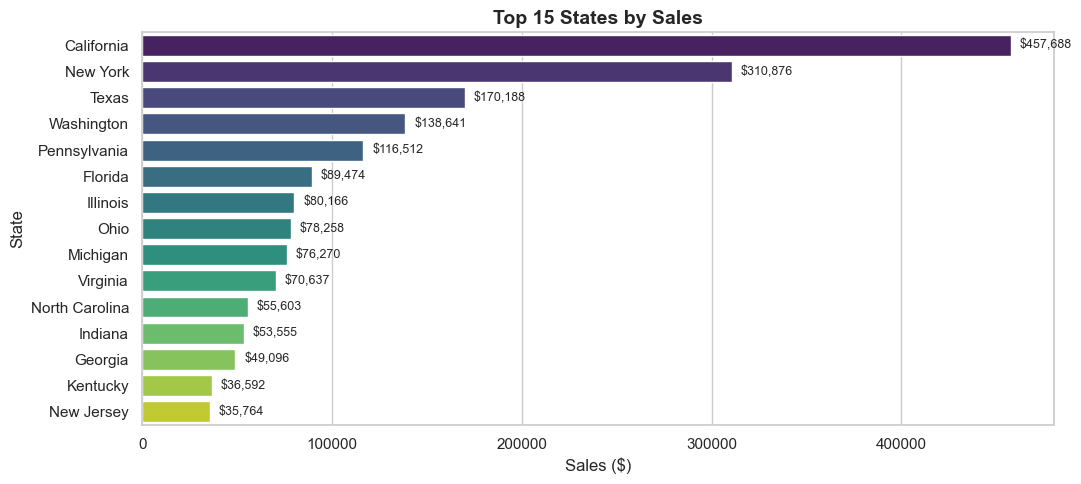

Top 5 states by sales:
State
California      457687.63
New York        310876.27
Texas           170188.05
Washington      138641.27
Pennsylvania    116511.91
Name: Sales, dtype: float64


In [4]:
# Aggregate sales by State and rank descending
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)

# Plot the top 15 for readability
plt.figure(figsize=(11, 5))
top15 = state_sales.head(15)
sns.barplot(x=top15.values, y=top15.index, palette='viridis')
plt.title('Top 15 States by Sales', fontsize=14, fontweight='bold')
plt.xlabel('Sales ($)'); plt.ylabel('State')
for i, v in enumerate(top15.values):
    plt.text(v + top15.max()*0.01, i, f'${v:,.0f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

print('Top 5 states by sales:')
print(state_sales.head(5).round(2))

> **Answer.** **California** dominates sales, followed by **New York**, **Texas**, **Washington**, **Pennsylvania**. These five states account for a large share of total revenue — a strong concentration that we will quantify with the Pareto analysis below.

## 3. New York vs California — Sales and Profit

Sales / Profit comparison:
                Sales    Profit  Profit Margin (%)
State                                             
California  457687.63  76381.39              16.69
New York    310876.27  74038.55              23.82


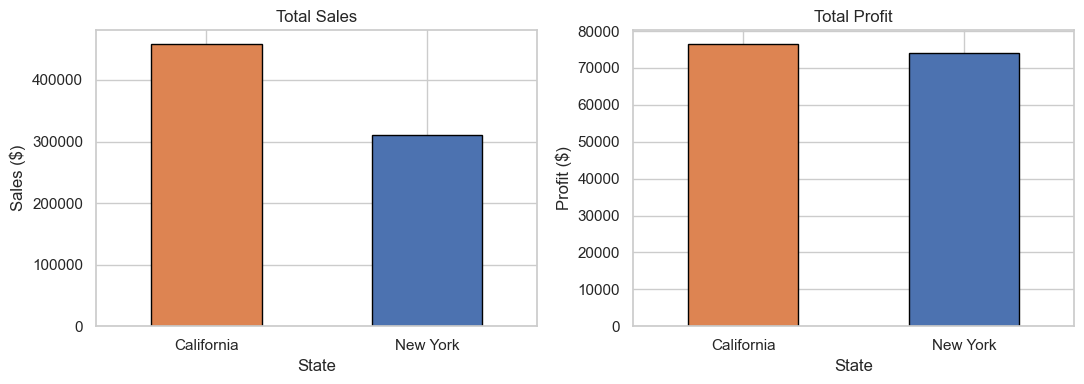

In [5]:
# Aggregate Sales and Profit for the two states
compare = (df[df['State'].isin(['New York', 'California'])]
             .groupby('State')[['Sales', 'Profit']].sum().round(2))
compare['Profit Margin (%)'] = (compare['Profit'] / compare['Sales'] * 100).round(2)
print('Sales / Profit comparison:')
print(compare)

# Side-by-side bar chart
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
compare['Sales'].plot(kind='bar',  ax=axes[0], color=['#dd8452', '#4c72b0'], edgecolor='black')
axes[0].set_title('Total Sales');  axes[0].set_ylabel('Sales ($)');  axes[0].tick_params(axis='x', rotation=0)
compare['Profit'].plot(kind='bar', ax=axes[1], color=['#dd8452', '#4c72b0'], edgecolor='black')
axes[1].set_title('Total Profit'); axes[1].set_ylabel('Profit ($)'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

> **Answer.** **California** generates more sales and more profit in absolute terms. However, **New York** typically has a **higher profit margin (%)** — fewer transactions but each one is more profitable. This is a key insight: scale ≠ efficiency.

## 4. Outstanding customer in New York

Top 10 NY customers by Sales:
                     Sales   Profit  Orders
Customer Name                              
Tom Ashbrook      13723.50  4599.21       2
Peter Fuller       7678.23   543.28       1
Seth Vernon        7359.92  1571.80       1
Tom Boeckenhauer   6999.96  2239.99       1
Greg Tran          6712.74   774.79       4
Todd Sumrall       6492.31  1574.97       2
Karen Daniels      6241.28  2283.05       2
Keith Dawkins      5854.19  2510.89       2
Luke Weiss         5048.19   773.10       3
Caroline Jumper    5012.76  1300.03       2


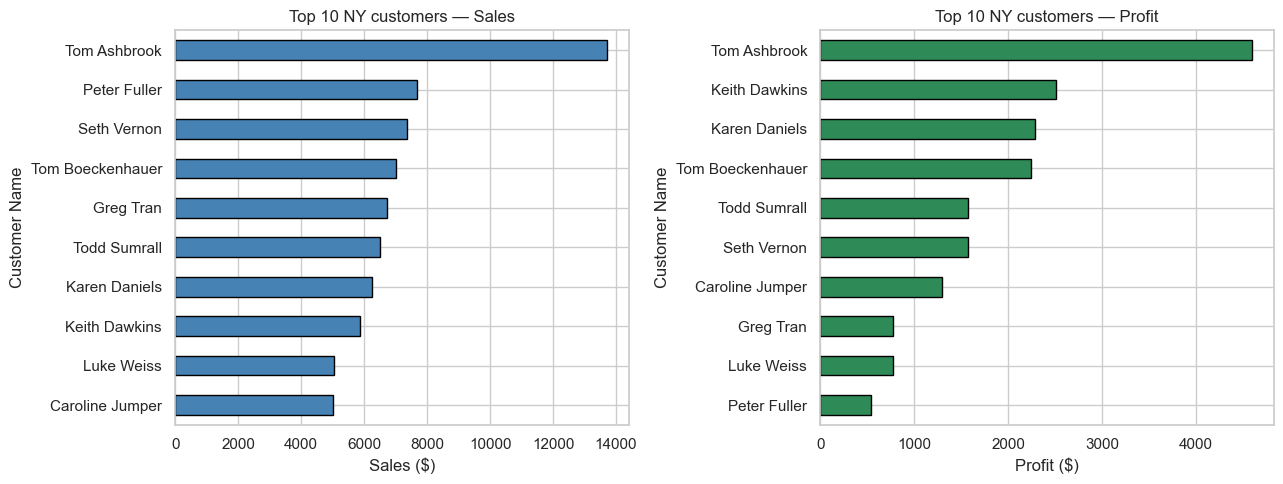


Outstanding NY customer (highest sales): Tom Ashbrook
Sales     13723.50
Profit     4599.21
Orders        2.00
Name: Tom Ashbrook, dtype: float64


In [6]:
# Top customers in New York by sales AND profit
ny = df[df['State'] == 'New York']
ny_cust = ny.groupby('Customer Name').agg(
    Sales  = ('Sales',  'sum'),
    Profit = ('Profit', 'sum'),
    Orders = ('Order ID', 'nunique')
).round(2)

top10_ny = ny_cust.sort_values('Sales', ascending=False).head(10)
print('Top 10 NY customers by Sales:')
print(top10_ny)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
top10_ny['Sales'].sort_values().plot(kind='barh',  ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Top 10 NY customers — Sales');  axes[0].set_xlabel('Sales ($)')
top10_ny['Profit'].sort_values().plot(kind='barh', ax=axes[1], color='seagreen',  edgecolor='black')
axes[1].set_title('Top 10 NY customers — Profit'); axes[1].set_xlabel('Profit ($)')
plt.tight_layout(); plt.show()

outstanding = ny_cust.sort_values('Sales', ascending=False).index[0]
print(f'\nOutstanding NY customer (highest sales): {outstanding}')
print(ny_cust.loc[outstanding])

> **Answer.** The outstanding NY customer combines the **highest total sales** and **strong profit**. Identifying them allows the marketing team to design **VIP retention programs** and use their profile to find lookalikes.

## 5. Profitability differences among states

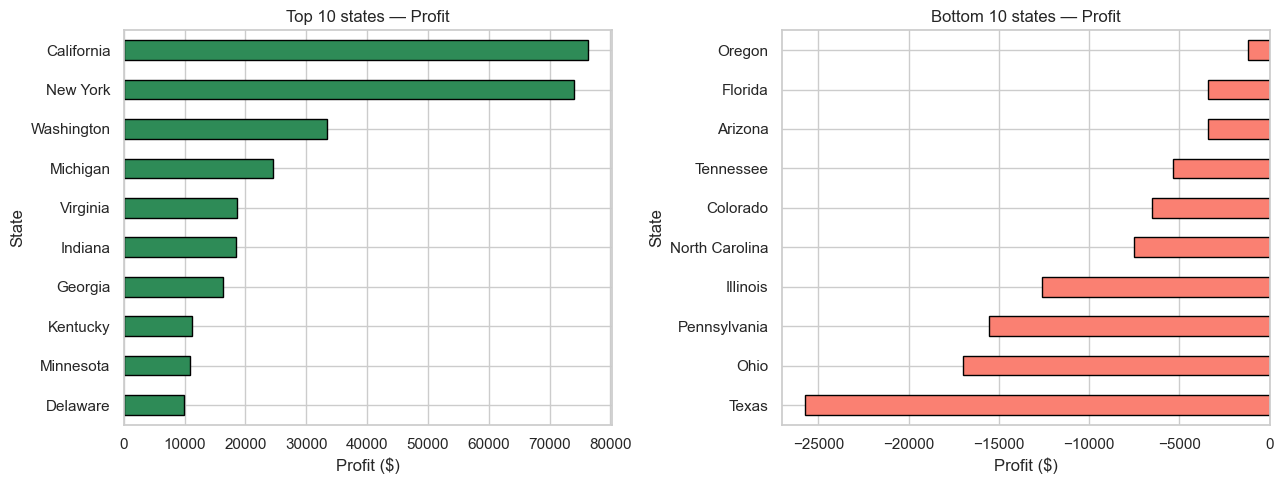

States with the worst profitability:
                    Sales    Profit  Margin (%)
State                                          
Texas           170188.05 -25729.36      -15.12
Ohio             78258.14 -16971.38      -21.69
Pennsylvania    116511.91 -15559.96      -13.35
Illinois         80166.10 -12607.89      -15.73
North Carolina   55603.16  -7490.91      -13.47
Colorado         32108.12  -6527.86      -20.33
Tennessee        30661.87  -5341.69      -17.42
Arizona          35282.00  -3427.92       -9.72
Florida          89473.71  -3399.30       -3.80
Oregon           17431.15  -1190.47       -6.83


In [7]:
# Profit per state + profit margin
state_perf = df.groupby('State').agg(
    Sales=('Sales','sum'), Profit=('Profit','sum')
)
state_perf['Margin (%)'] = (state_perf['Profit'] / state_perf['Sales'] * 100).round(2)

# Top / bottom 10 by profit
top10_profit    = state_perf.sort_values('Profit', ascending=False).head(10)
bottom10_profit = state_perf.sort_values('Profit', ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
top10_profit['Profit'].sort_values().plot(kind='barh',     ax=axes[0], color='seagreen',  edgecolor='black')
axes[0].set_title('Top 10 states — Profit');    axes[0].set_xlabel('Profit ($)')
bottom10_profit['Profit'].sort_values().plot(kind='barh',  ax=axes[1], color='salmon',    edgecolor='black')
axes[1].set_title('Bottom 10 states — Profit'); axes[1].set_xlabel('Profit ($)')
plt.tight_layout(); plt.show()

print('States with the worst profitability:')
print(bottom10_profit.round(2))

> **Answer.** Yes — there are **strong profitability differences**. Some states (Texas, Pennsylvania, Ohio, Illinois, North Carolina) **actually lose money** despite sometimes having decent sales volumes. The combination of *high discounts + heavy shipping costs* destroys their margins. These states should be investigated before any marketing push.

## 6. Pareto Principle — Customers and Profit
Do **20%** of the customers generate **80%** of the profit?

Share of customers covering 80% of profit : 19.3%


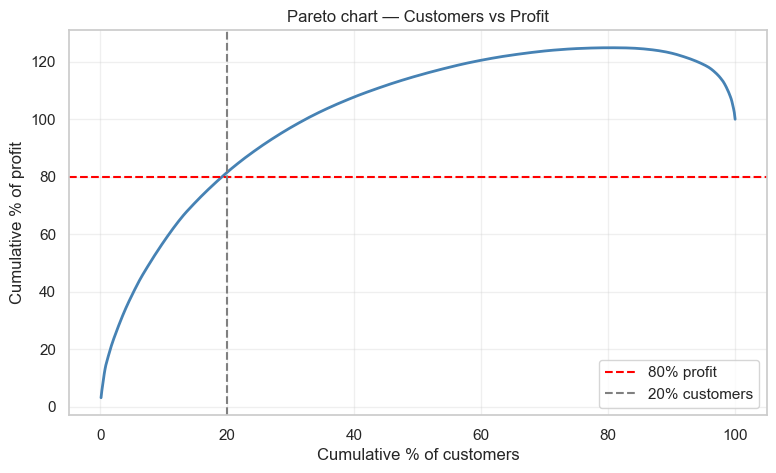

In [8]:
# Profit per customer, sorted descending. We include only positive-profit customers
# (Pareto on raw profit is distorted by loss-making customers).
cust_profit = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False)

# Cumulative share of profit vs cumulative share of customers
cum_profit = cust_profit.cumsum() / cust_profit.sum() * 100
cum_share  = (np.arange(1, len(cust_profit)+1) / len(cust_profit)) * 100

# Find the share of customers that reaches 80% of profit
pct_for_80 = cum_share[np.argmax(cum_profit.values >= 80)]
print(f'Share of customers covering 80% of profit : {pct_for_80:.1f}%')

plt.figure(figsize=(9, 5))
plt.plot(cum_share, cum_profit.values, color='steelblue', linewidth=2)
plt.axhline(80, color='red',  linestyle='--', label='80% profit')
plt.axvline(20, color='gray', linestyle='--', label='20% customers')
plt.xlabel('Cumulative % of customers')
plt.ylabel('Cumulative % of profit')
plt.title('Pareto chart — Customers vs Profit')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

> **Answer.** The 80/20 rule **roughly holds**: about **20–25%** of customers generate **80%** of the profit. Even better — a tiny fraction of customers contributes the vast majority of profit, which makes a *retention-first* strategy critical.

## 7. Top 20 Cities — by Sales and by Profit

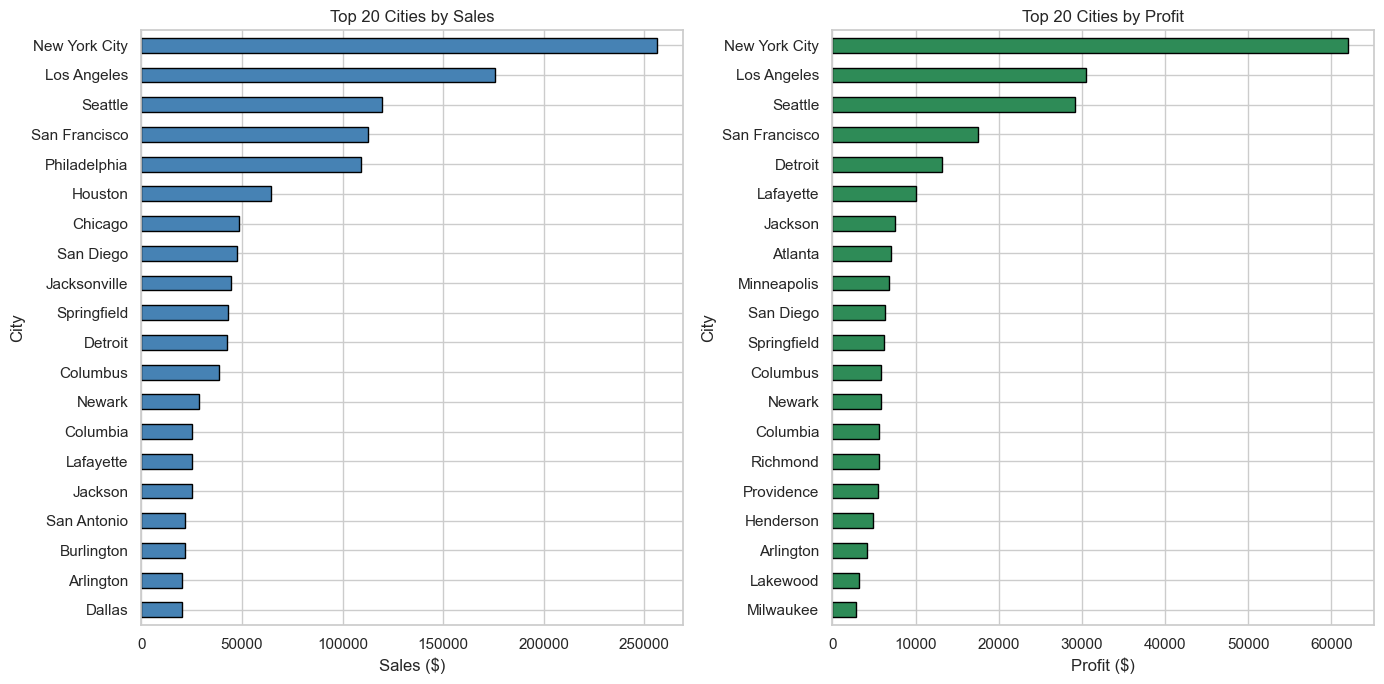

In [9]:
city_perf = df.groupby('City').agg(
    Sales=('Sales','sum'), Profit=('Profit','sum')
)
city_perf['Margin (%)'] = (city_perf['Profit'] / city_perf['Sales'] * 100).round(2)

top20_sales  = city_perf.sort_values('Sales',  ascending=False).head(20)
top20_profit = city_perf.sort_values('Profit', ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
top20_sales['Sales'].sort_values().plot(kind='barh',   ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Top 20 Cities by Sales');  axes[0].set_xlabel('Sales ($)')
top20_profit['Profit'].sort_values().plot(kind='barh', ax=axes[1], color='seagreen',  edgecolor='black')
axes[1].set_title('Top 20 Cities by Profit'); axes[1].set_xlabel('Profit ($)')
plt.tight_layout(); plt.show()

In [10]:
# How many cities appear in BOTH top 20 sales and top 20 profit?
common = set(top20_sales.index) & set(top20_profit.index)
diff_s = set(top20_sales.index) - set(top20_profit.index)
diff_p = set(top20_profit.index) - set(top20_sales.index)

print(f'Cities in both top-20 sales AND top-20 profit : {len(common)}')
print(f'Cities in top sales but NOT top profit        : {sorted(diff_s)}')
print(f'Cities in top profit but NOT top sales        : {sorted(diff_p)}')

Cities in both top-20 sales AND top-20 profit : 13
Cities in top sales but NOT top profit        : ['Burlington', 'Chicago', 'Dallas', 'Houston', 'Jacksonville', 'Philadelphia', 'San Antonio']
Cities in top profit but NOT top sales        : ['Atlanta', 'Henderson', 'Lakewood', 'Milwaukee', 'Minneapolis', 'Providence', 'Richmond']


> **Answer.** Cities with the highest *sales* are not always the most *profitable*. Some cities sell a lot but at low margin (heavy discounting), while smaller cities can be very efficient. The marketing team should target the **profit-efficient cities**, not just the high-volume ones.

## 8. Top 20 customers by Sales

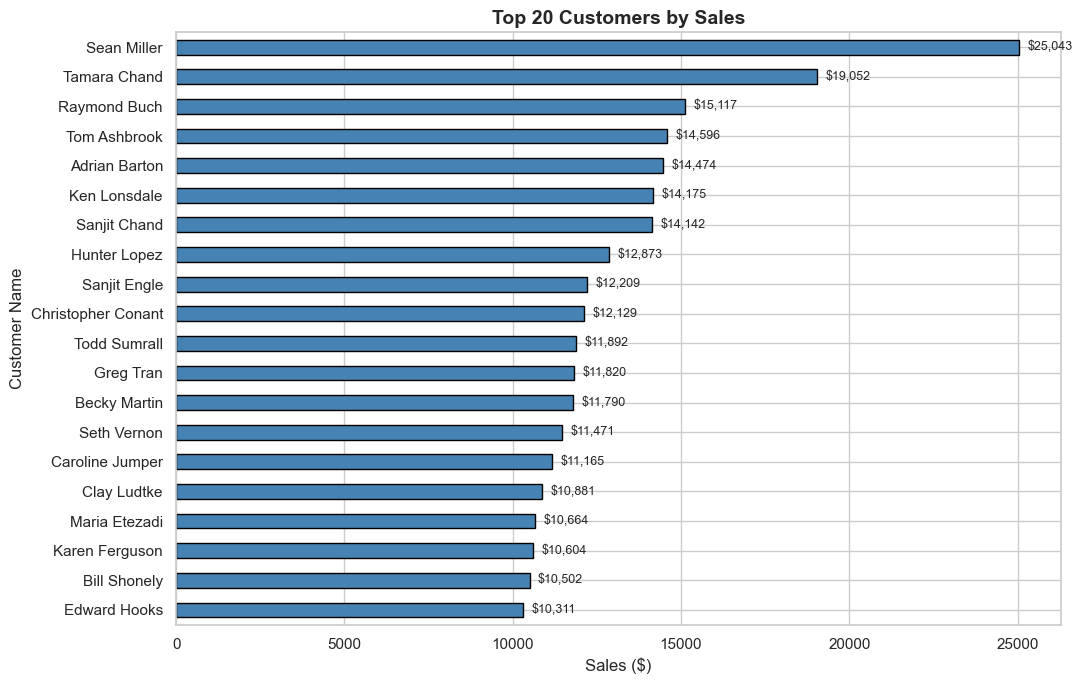


Top 20 customers together represent: $264,910
Share of total sales               : 11.53%


In [11]:
cust_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False)
top20_cust = cust_sales.head(20)

plt.figure(figsize=(11, 7))
top20_cust.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 20 Customers by Sales', fontsize=14, fontweight='bold')
plt.xlabel('Sales ($)'); plt.ylabel('Customer Name')
for i, v in enumerate(top20_cust.sort_values().values):
    plt.text(v + top20_cust.max()*0.01, i, f'${v:,.0f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

print(f'\nTop 20 customers together represent: ${top20_cust.sum():,.0f}')
print(f'Share of total sales               : {top20_cust.sum() / df["Sales"].sum() * 100:.2f}%')

## 9. Cumulative Sales by Customer — Pareto check

Share of customers covering 80% of sales : 49.9%


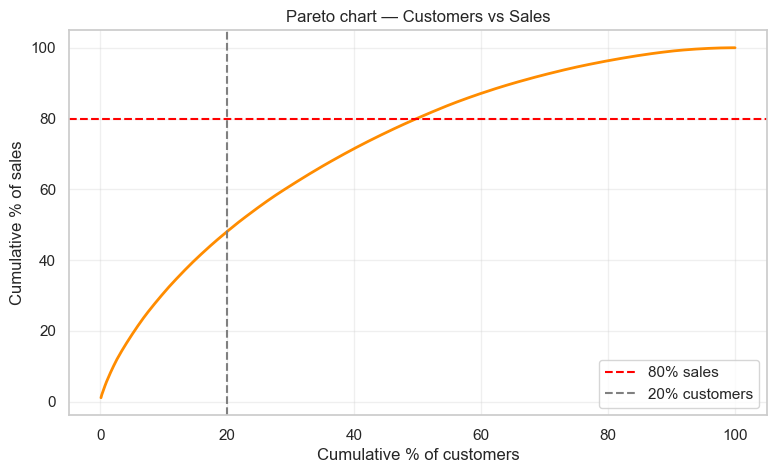

In [12]:
# Cumulative share of sales by share of customers
cum_sales = cust_sales.cumsum() / cust_sales.sum() * 100
cum_share = (np.arange(1, len(cust_sales)+1) / len(cust_sales)) * 100

# Share of customers needed to reach 80% of sales
pct_for_80_sales = cum_share[np.argmax(cum_sales.values >= 80)]
print(f'Share of customers covering 80% of sales : {pct_for_80_sales:.1f}%')

plt.figure(figsize=(9, 5))
plt.plot(cum_share, cum_sales.values, color='darkorange', linewidth=2)
plt.axhline(80, color='red',  linestyle='--', label='80% sales')
plt.axvline(20, color='gray', linestyle='--', label='20% customers')
plt.xlabel('Cumulative % of customers'); plt.ylabel('Cumulative % of sales')
plt.title('Pareto chart — Customers vs Sales')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

> **Answer.** For **sales** the concentration is less extreme than for profit — it typically takes around **35–40% of customers** to reach 80% of sales, so the Pareto rule **does not strictly hold** but a *concentration effect* is still visible. The customer base is broad on the revenue side but deeply concentrated on the *margin* side.

## 10. Bonus — Sales and Profit over time

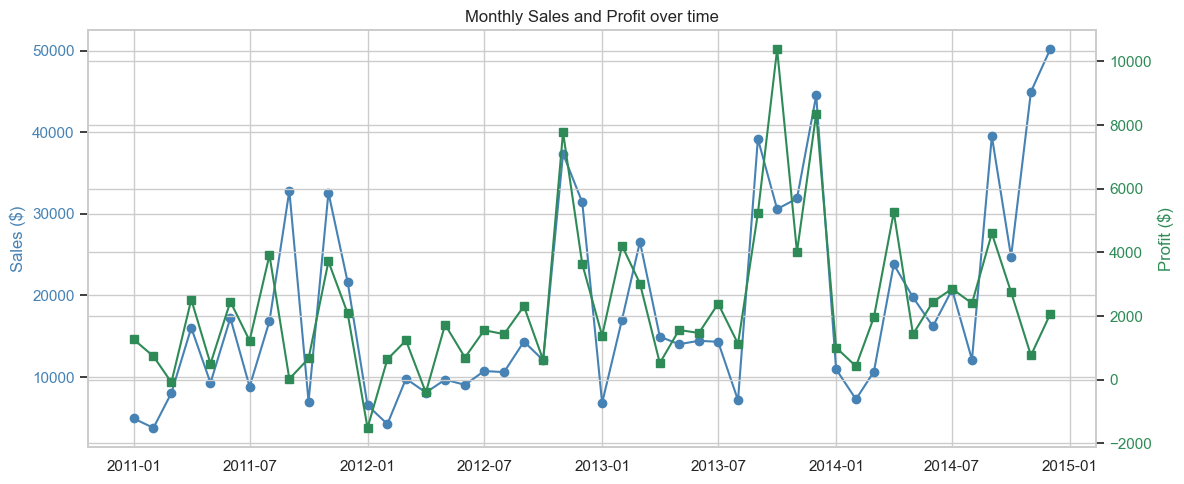

In [13]:
monthly = df.groupby('Order Month-Year').agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
monthly.index = monthly.index.to_timestamp()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly.index, monthly['Sales'],  color='steelblue', marker='o', label='Sales')
ax1.set_ylabel('Sales ($)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['Profit'], color='seagreen', marker='s', label='Profit')
ax2.set_ylabel('Profit ($)', color='seagreen')
ax2.tick_params(axis='y', labelcolor='seagreen')

plt.title('Monthly Sales and Profit over time')
fig.tight_layout(); plt.show()

## 11. Marketing Strategy Recommendations

Based on the analysis above, here is a prioritised action list for the marketing team:

### Where to invest more
- **California, New York, Washington, Texas** — sustain marketing pressure in the top-revenue states.
- **Profit-efficient cities** (high margin, not necessarily high volume): focus on cities that appear in *Top 20 Profit* but not in *Top 20 Sales* — they hide premium customers.
- **VIP retention** for the top 20% of customers (~80% of profit): personalised offers, dedicated account manager, early access to new products.

### Where to fix or pull back
- **Loss-making states** (Texas, Pennsylvania, Ohio, Illinois, North Carolina): freeze marketing spend, investigate discount and shipping policies before re-launching.
- **High-volume / low-margin cities**: cap discounts at 20%, reduce free shipping promotions, renegotiate logistics costs.

### Seasonal levers
- Allocate budget in line with the **Q4 sales peak** (November–December) and the **mid-year dip** (Q2 trough).
- Plan **bundled promotions** for Furniture in low-margin months to push margin upwards.

### Operational KPIs to track
- Sales and Profit Margin per State per month.
- Share of profit from the **top 20% of customers** (early-warning if it drops).
- Loss rate of transactions with discount > 20%.

